# **Étude comparative entre la capitalisation et la répartition pour le système de retraite français (1985-2025)**

## **🔍 Objectif du projet**
Ce projet vise à comparer les performances d’un **système de retraite par capitalisation** avec le **système actuel par répartition** en France.  
L’objectif est de modéliser un **fonds souverain hypothétique**, où les cotisations des actifs seraient investies sur les marchés financiers, et d’analyser **les rendements et les pensions** qu’un tel système aurait pu fournir entre 1985 et 2025.

---

## **📈 Choix des indices**
### **Pourquoi comparer le CAC40 et le S&P500 ?**
Nous définissons **deux scénarios de référence** :
1. **Le CAC40 : un scénario conservateur**  
   - Il représente **l’économie française**, qui n’a pas bénéficié d’une capitalisation massive via des fonds de pension.
   - Si un **fonds souverain français** avait été instauré dès 1985, la capitalisation du CAC40 aurait logiquement été renforcée.

2. **Le S&P500 : un scénario optimiste**  
   - Il est **déjà massivement soutenu par des fonds de pension américains**.
   - Il permet **d’estimer ce que pourrait être un CAC40 dans un modèle capitalisé performant**.

💡 **Pourquoi cette comparaison ?**  
Cette approche permet d’avoir **une fourchette réaliste** entre un scénario prudent (**le CAC40**) et une projection optimiste (**le S&P500**), illustrant ce qu’un système capitalisé aurait pu générer en France.

---

### **🔗 Rôle des autres indices**
- **Le WGBI (World Government Bond Index)** est utilisé comme **référence obligataire** pour la partie obligations des portefeuilles.

---

## **📊 Méthodologie**
### **1️⃣ Collecte et prétraitement des données**
- Récupération des historiques du **CAC40, S&P500 et WGBI**.
- **Reconstruction des données manquantes (backfill)** pour garantir une continuité temporelle.
- **Calcul des variations mensuels** pour assurer le backtest des diférents portefeuils.

### **2️⃣ Simulation des allocations**
Nous modélisons **4 portefeuilles types**, répartis de la manière suivante :
- **50% actions / 50% obligations** (CAC40/WGBI et S&P500/WGBI).
- **75% actions / 25% obligations** (CAC40/WGBI et S&P500/WGBI).

**Hypothèse clé** : Les cotisations mensuelles sont **progressivement investies** dans ces portefeuilles (**DCA – Dollar Cost Averaging**).

 **Frais de gestion** : Un taux de 0,5% annuel de frais à été pris en compte, ce taux est un juste milieux entre les taux appliquées dans les différentes formes de fonds (souverain, ETF, PE et)

### **3️⃣ Calcul des rendements et pensions**
- **Estimation des rendements annualisés** des différentes allocations.
- **Détermination du taux de prélèvement optimal** pour garantir une pension stable sur **25 ans**, en cohérence avec l’espérance de vie moyenne des retraités.
- Ce taux permet de **maximiser les retraits** tout en assurant la viabilité du fonds.

### **4️⃣ Prise en compte de la solidarité**
- **Intégration des dispositifs de solidarité retraite** (ASPA, ASV) pour les bénéficiaires n’ayant pas cotisé pleinement.
- **Ajustement du modèle** pour inclure ces coûts dans l’estimation des pensions viables.

### **5️⃣ Analyse des résultats**
- **Comparaison des pensions obtenues** avec celles du système actuel.
- **Évaluation de l’impact des différentes allocations** et des rendements observés.
- **Visualisation des performances** du fonds de retraite hypothétique.

---


In [58]:
import os

# Charger le chemin depuis le fichier texte
with open("../.path_repo.txt", "r") as f:
    path_repo = f.read().strip()

os.chdir(path_repo)

FileNotFoundError: [Errno 2] No such file or directory: '../.path_repo.txt'

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Import du dataset cleané et augmenté (backfill des valleurs manquantes)
df = pd.read_csv(r"data\processed\DataFrame_backfilled.csv",  index_col='Date', parse_dates=['Date'])

## 📌 Création des colonnes de variation

Afin de pouvoir calculer la performance des portefeuilles dans les étapes suivantes, nous créons des colonnes représentant la variation mensuelle de chaque indice.  
L’index du DataFrame étant basé sur des dates mensuelles, la variation est calculée par rapport au mois précédent pour chaque indice.

🔹 Ces variations permettront ensuite de simuler l’effet des performances mensuelles sur un capital investi, en les appliquant successivement au fil du temps (logique de capitalisation).

In [ ]:
df['SP500_var'] = df['SP500_TR'].pct_change()
df['CAC40_var'] = df['CAC40_TR'].pct_change()
df['WGBI_var'] = df['WGBI_TR'].pct_change()
df

,SP500_TR,CAC40_TR,WGBI_TR,SP500_var,CAC40_var,WGBI_var
Date,,,,,,
1985-01-01,172.176132,692.288669,10000.000000,NaN,NaN,NaN
1985-02-01,180.194935,720.457778,10235.623791,0.046573,0.040690,0.023562
1985-03-01,181.992612,726.738050,9832.991278,0.009976,0.008717,-0.039336
1985-04-01,182.598183,728.870481,10019.526779,0.003327,0.002934,0.018970
1985-05-01,183.032920,730.405192,10250.878162,0.002381,0.002106,0.023090
...,...,...,...,...,...,...
2024-08-01,12086.490234,23179.092370,55630.313495,0.013064,-0.025147,0.000550
2024-09-01,12292.099609,23646.248645,56093.077188,0.017012,0.020154,0.008319
2024-10-01,12598.030273,23654.766305,55534.603307,0.024888,0.000360,-0.009956


## 📌 Création du DataFrame des salaires et cotisations mensuels

Les salaires médians de 1985 et 2025 sont extraits de l’INSEE. \
Entre ces deux dates, les salaires sont interpolés annuellement à l’aide d’un taux de croissance constant.  
Même principe pour les taux de cotisation. \
Cela permet de simuler l’évolution mensuelle des cotisations d’un salarié moyen (ou plus exactement salarié médian).

In [ ]:
# Définir les données pour chaque catégorie de salaire
categories_salaires = {
    'SMIC': {
        'salaire_1985': 618,
        'salaire_2025': 1811,
        'taux_1985': 16.35,
        'taux_2025': 25.62
    },
    'median': {
        'salaire_1985': 1156,
        'salaire_2025': 2735,
        'taux_1985': 16.35,
        'taux_2025': 25.62
    },
    'D9': {
        'salaire_1985': 1860,
        'salaire_2025': 5248,
        'taux_1985': 11.31,
        'taux_2025': 20.51
    }
}

# Calcul des années de début et fin
start_year = df.index.year.min()
end_year = df.index.year.max()
nb_annees = end_year - start_year

# Création des dates pour chaque mois dans la période
dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='MS')

# Dictionnaire pour stocker les DataFrames de chaque catégorie
dataframes_salaires = {}

# Boucle pour traiter chaque catégorie de salaire
for categorie, donnees in categories_salaires.items():
    
    # Extraction des données de la catégorie
    salaire_1985 = donnees['salaire_1985']
    salaire_2025 = donnees['salaire_2025']
    taux_1985 = donnees['taux_1985']
    taux_2025 = donnees['taux_2025']
    
    # Calcul du taux d'augmentation annuel pour le salaire
    taux_augmentation_annuel_salaire = (salaire_2025 / salaire_1985) ** (1 / nb_annees) - 1
    
    # Calcul du taux d'augmentation annuel du taux de cotisation
    taux_augmentation_annuel_cotisation = (taux_2025 / taux_1985) ** (1 / nb_annees) - 1
    
    # Calcul du salaire mensuel pour chaque année
    salaires = [salaire_1985 * (1 + taux_augmentation_annuel_salaire) ** (year - start_year) 
                for year in range(start_year, end_year + 1)]
    
    # Calcul du taux de cotisation pour chaque année
    taux_cotisations = [taux_1985 * (1 + taux_augmentation_annuel_cotisation) ** (year - start_year) 
                        for year in range(start_year, end_year + 1)]
    
    # Répéter les salaires et taux de cotisation pour chaque mois
    salaire_mensuel = np.repeat(salaires, 12)
    taux_cotisation_annuel = np.repeat(taux_cotisations, 12)
    
    # Ajuster la longueur pour correspondre au nombre de dates
    salaire_mensuel = salaire_mensuel[:len(dates)]
    taux_cotisation_annuel = taux_cotisation_annuel[:len(dates)]
    
    # Calcul des cotisations mensuelles
    cotisations = salaire_mensuel * (taux_cotisation_annuel / 100)
    
    # Création du DataFrame pour cette catégorie
    salaire_df = pd.DataFrame({
        'Date': dates,
        'salaire_mensuel': salaire_mensuel,
        'taux_cotisation': taux_cotisation_annuel,
        'cotisations': cotisations
    })
    
    # Ajout de la colonne des cotisations cumulées
    salaire_df["cotisations_cumulees"] = salaire_df["cotisations"].cumsum()
    
    # Stockage du DataFrame dans le dictionnaire
    dataframes_salaires[categorie] = salaire_df
    
    # Affichage des premières lignes pour vérification
    print(f"\n=== Catégorie: {categorie.upper()} ===")
    print(f"Taux d'augmentation annuel salaire: {taux_augmentation_annuel_salaire:.4f} ({taux_augmentation_annuel_salaire*100:.2f}%)")
    print(f"Taux d'augmentation annuel cotisation: {taux_augmentation_annuel_cotisation:.4f} ({taux_augmentation_annuel_cotisation*100:.2f}%)")
    print(salaire_df.head())
    print(f"Dernières valeurs:")
    print(salaire_df.tail(2))

# df_smic = dataframes_salaires['SMIC']
# df_median = dataframes_salaires['median'] 
# df_d9 = dataframes_salaires['D9']

# DataFrame consolidé avec toutes les catégories
df_cotisation = pd.DataFrame({'Date': dates})
for categorie, df_cat in dataframes_salaires.items():
    df_cotisation[f'salaire_{categorie}'] = df_cat['salaire_mensuel']
    df_cotisation[f'taux_{categorie}'] = df_cat['taux_cotisation']
    df_cotisation[f'cotisations_{categorie}'] = df_cat['cotisations']
    df_cotisation[f'cotisations_cumulees_{categorie}'] = df_cat['cotisations_cumulees']

print(f"\n=== DATAFRAME CONSOLIDÉ ===")
df_cotisation.head()


=== Catégorie: SMIC ===
Taux d'augmentation annuel salaire: 0.0280 (2.80%)
Taux d'augmentation annuel cotisation: 0.0116 (1.16%)
        Date  salaire_mensuel  taux_cotisation  cotisations  \
0 1985-01-01            618.0            16.35      101.043   
1 1985-02-01            618.0            16.35      101.043   
2 1985-03-01            618.0            16.35      101.043   
3 1985-04-01            618.0            16.35      101.043   
4 1985-05-01            618.0            16.35      101.043   

   cotisations_cumulees  
0               101.043  
1               202.086  
2               303.129  
3               404.172  
4               505.215  
Dernières valeurs:
          Date  salaire_mensuel  taux_cotisation  cotisations  \
478 2024-11-01           1811.0            25.62     463.9782   
479 2024-12-01           1811.0            25.62     463.9782   

     cotisations_cumulees  
478         114371.569036  
479         114835.547236  

=== Catégorie: MEDIAN ===
Taux d'au

,Date,salaire_SMIC,taux_SMIC,cotisations_SMIC,cotisations_cumulees_SMIC,salaire_median,taux_median,cotisations_median,cotisations_cumulees_median,salaire_D9,taux_D9,cotisations_D9,cotisations_cumulees_D9
0,1985-01-01,618.0,16.35,101.043,101.043,1156.0,16.35,189.006,189.006,1860.0,11.31,210.366,210.366
1,1985-02-01,618.0,16.35,101.043,202.086,1156.0,16.35,189.006,378.012,1860.0,11.31,210.366,420.732
2,1985-03-01,618.0,16.35,101.043,303.129,1156.0,16.35,189.006,567.018,1860.0,11.31,210.366,631.098
3,1985-04-01,618.0,16.35,101.043,404.172,1156.0,16.35,189.006,756.024,1860.0,11.31,210.366,841.464
4,1985-05-01,618.0,16.35,101.043,505.215,1156.0,16.35,189.006,945.030,1860.0,11.31,210.366,1051.830


In [ ]:
# Fusionner les données de salaire avec les indices boursiers sur la date
df_ = df_cotisation.merge(df[["SP500_var","CAC40_var","WGBI_var"]], on='Date', how='left')
df_.set_index("Date", inplace=True)
# Vérification
df_

,salaire_SMIC,taux_SMIC,cotisations_SMIC,cotisations_cumulees_SMIC,salaire_median,taux_median,cotisations_median,cotisations_cumulees_median,salaire_D9,taux_D9,cotisations_D9,cotisations_cumulees_D9,SP500_var,CAC40_var,WGBI_var
Date,,,,,,,,,,,,,,,
1985-01-01,618.0,16.35,101.0430,101.043000,1156.0,16.35,189.006,189.006000,1860.0,11.31,210.3660,210.366000,NaN,NaN,NaN
1985-02-01,618.0,16.35,101.0430,202.086000,1156.0,16.35,189.006,378.012000,1860.0,11.31,210.3660,420.732000,0.046573,0.040690,0.023562
1985-03-01,618.0,16.35,101.0430,303.129000,1156.0,16.35,189.006,567.018000,1860.0,11.31,210.3660,631.098000,0.009976,0.008717,-0.039336
1985-04-01,618.0,16.35,101.0430,404.172000,1156.0,16.35,189.006,756.024000,1860.0,11.31,210.3660,841.464000,0.003327,0.002934,0.018970
1985-05-01,618.0,16.35,101.0430,505.215000,1156.0,16.35,189.006,945.030000,1860.0,11.31,210.3660,1051.830000,0.002381,0.002106,0.023090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,1811.0,25.62,463.9782,112979.634436,2735.0,25.62,700.707,185315.402692,5248.0,20.51,1076.3648,251713.636576,0.013064,-0.025147,0.000550
2024-09-01,1811.0,25.62,463.9782,113443.612636,2735.0,25.62,700.707,186016.109692,5248.0,20.51,1076.3648,252790.001376,0.017012,0.020154,0.008319
2024-10-01,1811.0,25.62,463.9782,113907.590836,2735.0,25.62,700.707,186716.816692,5248.0,20.51,1076.3648,253866.366176,0.024888,0.000360,-0.009956


## 📌 Simulation de la capitalisation

L’objectif de cette section est de modéliser ce qu’aurait pu générer un système de retraite par capitalisation, en supposant que les cotisations mensuelles n’avaient pas été immédiatement redistribuées, mais investies sur les marchés financiers.

### Approche en DCA (Dollar Cost Averaging) 🏦
Chaque mois, les cotisations sont investies progressivement dans un portefeuille financier au lieu d’être immédiatement reversées aux retraités.

### Mécanisme d’accumulation 💰
Chaque mois, la valeur du capital est mise à jour en appliquant la performance des indices correspondant à l’allocation choisie.  
Les cotisations suivantes s’ajoutent au capital déjà constitué, créant un effet de capitalisation renforcé par les intérêts composés.

### Frais de gestion 🔧
Pour garantir une approche réaliste dans ce scénario hypothétique, un taux de frais de gestion de 0,5 % a été retenu. \
Ce niveau constitue un bon compromis entre les très faibles frais des ETF (environ 0,1 %) et les frais parfois élevés des gestionnaires actifs privés (jusqu’à 2 %).
Étant donné que notre scénario repose sur un fonds public, un taux de 0,5 % paraît donc raisonnable et crédible.

In [ ]:
# Paramètre : frais de gestion annuels
frais_annuels = 0.005  # 0.5% annuel
frais_mensuels = (1 + frais_annuels) ** (1/12) - 1

# Définition des portefeuilles avec leurs configurations
portefeuilles = {
    "CAC40_50/50": {
        "actions_col": "CAC40_var",
        "obligations_col": "WGBI_var",
        "poids_actions": 0.5,
        "poids_obligations": 0.5
    },
    "SNP500_50/50": {
        "actions_col": "SP500_var",
        "obligations_col": "WGBI_var",
        "poids_actions": 0.5,
        "poids_obligations": 0.5
    },
    "CAC40_75/25": {
        "actions_col": "CAC40_var",
        "obligations_col": "WGBI_var",
        "poids_actions": 0.75,
        "poids_obligations": 0.25
    },
    "SNP500_75/25": {
        "actions_col": "SP500_var",
        "obligations_col": "WGBI_var",
        "poids_actions": 0.75,
        "poids_obligations": 0.25
    }
}

# Liste des colonnes de cotisation cumulée
cotisation_cols = ["cotisations_SMIC", "cotisations_median", "cotisations_D9"]

# Initialisation des colonnes de simulation (4 portefeuilles × 3 profils)
for portefeuille in portefeuilles:
    for cot_col in cotisation_cols:
        suffix = cot_col.split("_")[-1]
        new_col = f"{portefeuille}_{suffix}"
        df_[new_col] = df_[cot_col]

# Simulation de capitalisation
for i in range(1, len(df_)):
    for portefeuille, config in portefeuilles.items():
        for cot_col in cotisation_cols:
            suffix = cot_col.split("_")[-1]
            col_name = f"{portefeuille}_{suffix}"

            # Indices
            col_idx = df_.columns.get_loc(col_name)
            cot_idx = df_.columns.get_loc(cot_col)
            act_idx = df_.columns.get_loc(config["actions_col"])
            obl_idx = df_.columns.get_loc(config["obligations_col"])

            valeur_precedente = df_.iloc[i - 1, col_idx]
            var_actions = df_.iloc[i, act_idx]
            var_obligations = df_.iloc[i, obl_idx]
            variation = config["poids_actions"] * var_actions + config["poids_obligations"] * var_obligations
            nouvelle_valeur = valeur_precedente * (1 + variation - frais_mensuels) + df_.iloc[i, cot_idx]

            df_.iloc[i, col_idx] = nouvelle_valeur

# Vérification
print("=== RÉSULTATS DES PORTEFEUILLES ===")
colonnes_portefeuilles = list(portefeuilles.keys())
print("Dernières valeurs:")
for portefeuille in portefeuilles:
    for cot_col in cotisation_cols:
        suffix = cot_col.split("_")[-1]
        new_col = f"{portefeuille}_{suffix}"
        valeur_finale = df_[new_col].iloc[-1]
        total_cotisations = df_[cot_col].sum()
        rendement_annuel = (valeur_finale / total_cotisations) ** (1 / (len(df_) / 12)) - 1
        print(f"{new_col}: Valeur final = {valeur_finale:,.0f}€")

=== RÉSULTATS DES PORTEFEUILLES ===
Dernières valeurs:
CAC40_50/50_SMIC: Valeur final = 304,488€
CAC40_50/50_median: Valeur final = 522,964€
CAC40_50/50_D9: Valeur final = 662,974€
SNP500_50/50_SMIC: Valeur final = 433,631€
SNP500_50/50_median: Valeur final = 748,063€
SNP500_50/50_D9: Valeur final = 941,959€
CAC40_75/25_SMIC: Valeur final = 370,710€
CAC40_75/25_median: Valeur final = 639,306€
CAC40_75/25_D9: Valeur final = 805,475€
SNP500_75/25_SMIC: Valeur final = 653,607€
SNP500_75/25_median: Valeur final = 1,135,117€
SNP500_75/25_D9: Valeur final = 1,414,874€


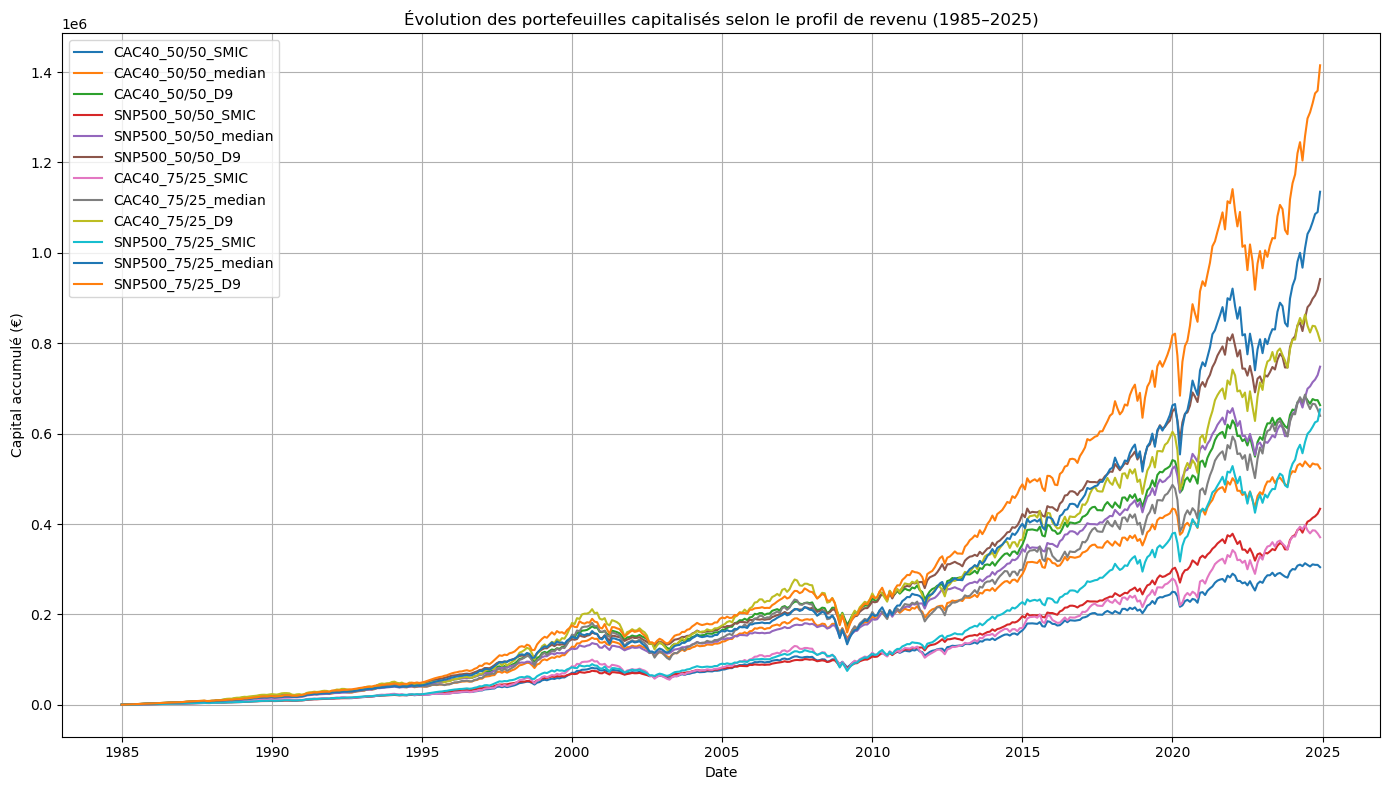

In [ ]:
plt.figure(figsize=(14, 8))

for col in df_.columns:
    if col.startswith(("CAC40", "SNP500")) and any(income in col for income in ["SMIC", "median", "D9"]):
        plt.plot(df_.index, df_[col], label=col)

plt.legend()
plt.title("Évolution des portefeuilles capitalisés selon le profil de revenu (1985–2025)")
plt.xlabel("Date")
plt.ylabel("Capital accumulé (€)")
plt.grid(True)
plt.tight_layout()
plt.savefig("charts/perf_portefeuilles_par_revenu_auto.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df_

,salaire_SMIC,taux_SMIC,cotisations_SMIC,cotisations_cumulees_SMIC,salaire_median,taux_median,cotisations_median,cotisations_cumulees_median,salaire_D9,taux_D9,...,CAC40_50/50_D9,SNP500_50/50_SMIC,SNP500_50/50_median,SNP500_50/50_D9,CAC40_75/25_SMIC,CAC40_75/25_median,CAC40_75/25_D9,SNP500_75/25_SMIC,SNP500_75/25_median,SNP500_75/25_D9
Date,,,,,,,,,,,,,,,,,,,,,
1985-01-01,618.0,16.35,101.0430,101.043000,1156.0,16.35,189.006,189.006000,1860.0,11.31,...,210.366000,101.043000,189.006000,210.366000,101.043000,189.006000,210.366000,101.043000,1.890060e+02,2.103660e+02
1985-02-01,618.0,16.35,101.0430,202.086000,1156.0,16.35,189.006,378.012000,1860.0,11.31,...,427.402788,205.587352,384.561455,428.021624,205.722765,384.814752,428.303546,206.168625,3.856488e+02,4.292318e+02
1985-03-01,618.0,16.35,101.0430,303.129000,1156.0,16.35,189.006,567.018000,1860.0,11.31,...,631.047716,303.526854,567.762205,631.926310,306.002118,572.392312,637.079675,306.641033,5.735874e+02,6.384099e+02
1985-04-01,618.0,16.35,101.0430,404.172000,1156.0,16.35,189.006,756.024000,1860.0,11.31,...,848.062811,407.827666,762.862108,849.074898,409.042567,765.134640,851.604254,409.776080,7.665067e+02,8.531314e+02
1985-05-01,618.0,16.35,101.0430,505.215000,1156.0,16.35,189.006,945.030000,1860.0,11.31,...,1068.760006,513.894994,961.266364,1069.901272,512.922686,959.447613,1067.876980,513.745876,9.609874e+02,1.069591e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,1811.0,25.62,463.9782,112979.634436,2735.0,25.62,700.707,185315.402692,5248.0,20.51,...,666114.533008,408142.165173,704478.332588,886323.601980,379213.758999,654368.367380,823677.697794,605645.605793,1.052228e+06,1.310775e+06
2024-09-01,1811.0,25.62,463.9782,113443.612636,2735.0,25.62,700.707,186016.109692,5248.0,20.51,...,676397.044337,413605.604671,713808.415477,898256.822366,386040.784880,666049.100878,838575.028580,614844.538753,1.068104e+06,1.330756e+06
2024-10-01,1811.0,25.62,463.9782,113907.590836,2735.0,25.62,700.707,186716.816692,5248.0,20.51,...,673946.871926,416985.661268,719541.746011,905666.242824,385487.697760,664995.031005,837442.078684,624999.409758,1.085640e+06,1.352807e+06


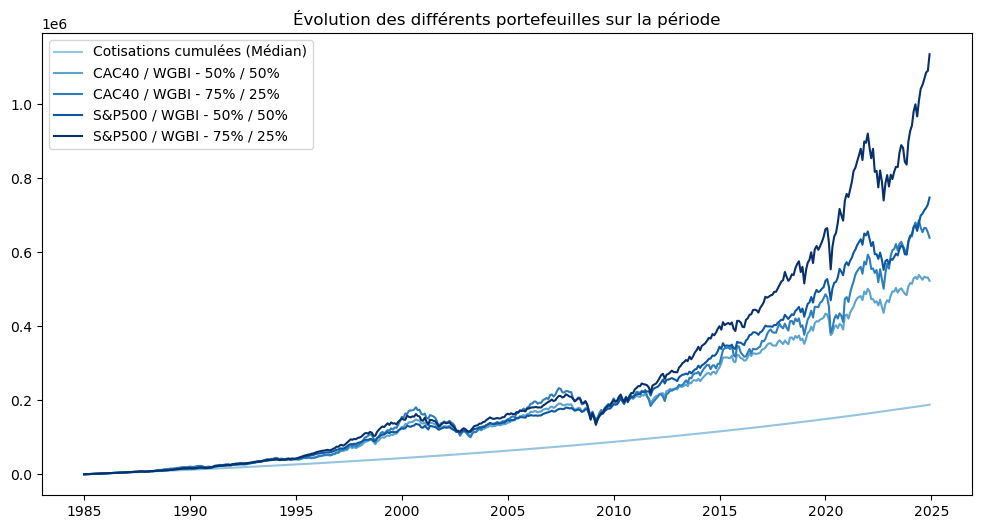

In [ ]:
allocations = ['cotisations_cumulees_median', 'CAC40_50/50_median', 'CAC40_75/25_median', 'SNP500_50/50_median', 'SNP500_75/25_median']
colors = plt.cm.Blues(np.linspace(0.4, 1, len(allocations)))

plt.figure(figsize=(12,6))
plt.plot(df_.index, df_["cotisations_cumulees_median"], label="Cotisations cumulées (Médian)", color=colors[0])
plt.plot(df_.index, df_["CAC40_50/50_median"], label="CAC40 / WGBI - 50% / 50%", color=colors[1])
plt.plot(df_.index, df_["CAC40_75/25_median"], label="CAC40 / WGBI - 75% / 25%", color=colors[2])
plt.plot(df_.index, df_["SNP500_50/50_median"], label="S&P500 / WGBI - 50% / 50%", color=colors[3])
plt.plot(df_.index, df_["SNP500_75/25_median"], label="S&P500 / WGBI - 75% / 25%", color=colors[4])

plt.legend()
plt.title("Évolution des différents portefeuilles sur la période")
plt.savefig("charts/perf_portefeuilles_blue.png", dpi=300, bbox_inches='tight')
plt.show()

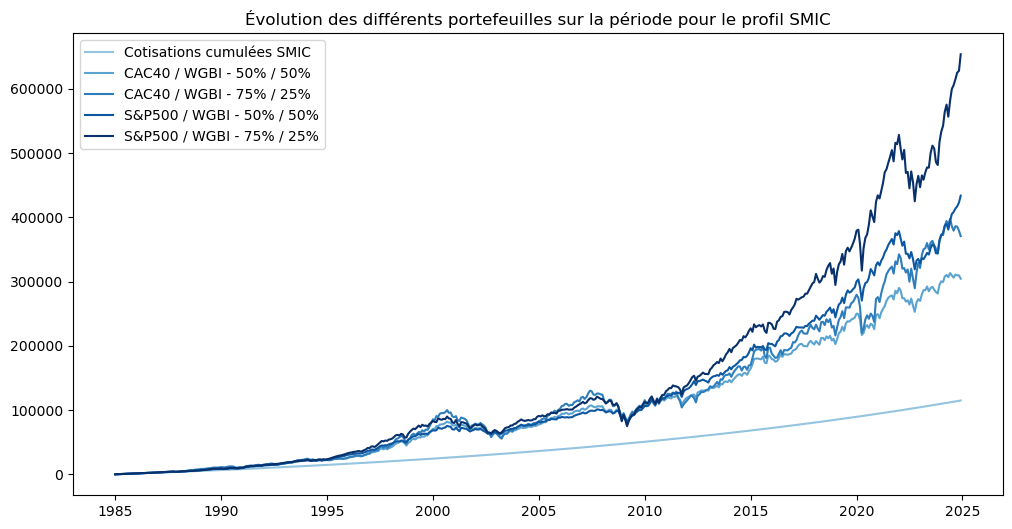

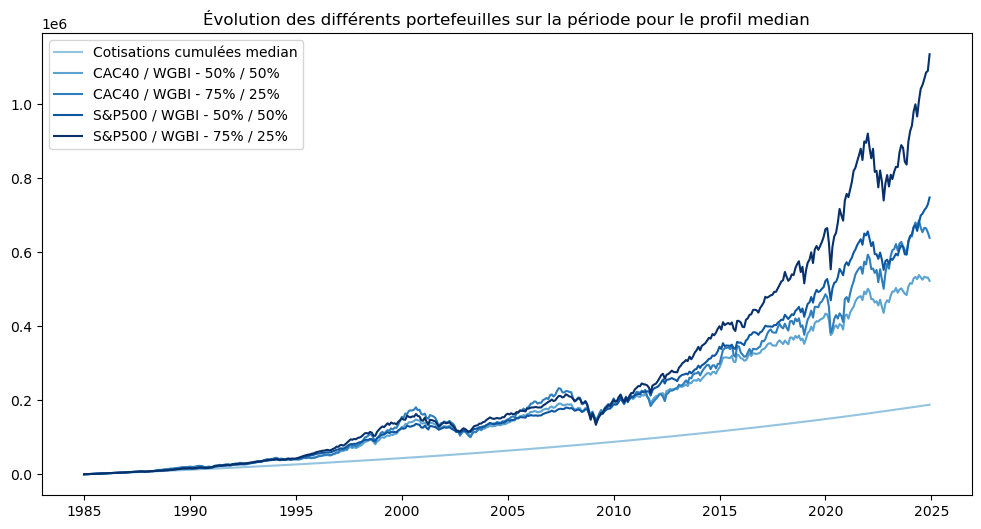

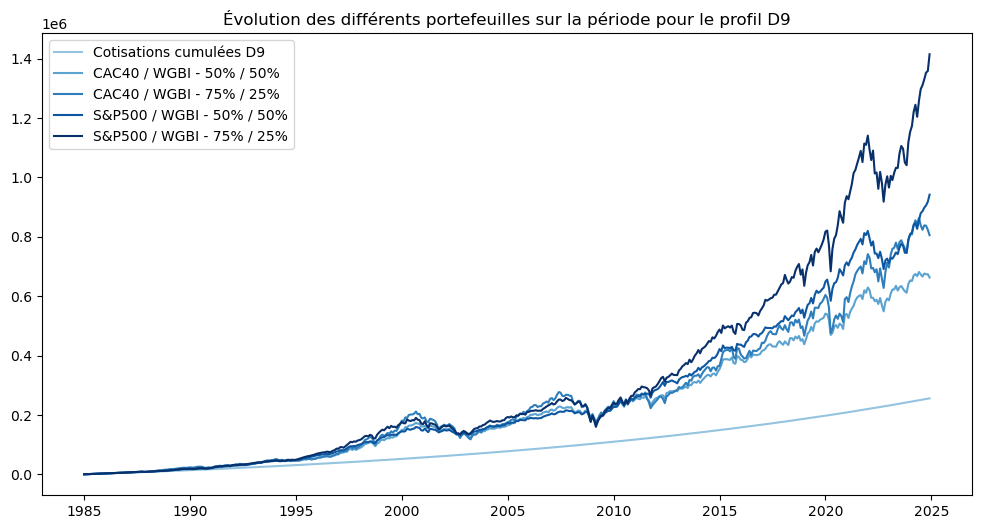

In [ ]:
# Affichage des performances

revenus = ["SMIC","median","D9"]

for revenu in revenus:
    allocations = [f'cotisations_cumulees_{revenu}', f'CAC40_50/50_{revenu}', f'CAC40_75/25_{revenu}', f'SNP500_50/50_{revenu}', f'SNP500_75/25_{revenu}']
    colors = plt.cm.Blues(np.linspace(0.4, 1, len(allocations)))

    plt.figure(figsize=(12,6))
    plt.plot(df_.index, df_[f"cotisations_cumulees_{revenu}"], label=f"Cotisations cumulées {revenu}", color=colors[0])
    plt.plot(df_.index, df_[f"CAC40_50/50_{revenu}"], label="CAC40 / WGBI - 50% / 50%", color=colors[1])
    plt.plot(df_.index, df_[f"CAC40_75/25_{revenu}"], label="CAC40 / WGBI - 75% / 25%", color=colors[2])
    plt.plot(df_.index, df_[f"SNP500_50/50_{revenu}"], label="S&P500 / WGBI - 50% / 50%", color=colors[3])
    plt.plot(df_.index, df_[f"SNP500_75/25_{revenu}"], label="S&P500 / WGBI - 75% / 25%", color=colors[4])

    plt.legend()
    plt.title(f"Évolution des différents portefeuilles sur la période pour le profil {revenu}")
    plt.savefig("charts/perf_portefeuilles_blue.png", dpi=300, bbox_inches='tight')
    plt.show()

## 📌 Résultat de la capitalisation :

À partir du DataFrame des simulations, nous extrayons et stockons dans des variables clés les montants finaux de capitalisation.  
Ces montants correspondent à la somme totale des cotisations versées, ainsi qu’à leur valorisation au fil du temps grâce aux rendements des marchés financiers.

🔹 Nous calculons ensuite des moyennes par type d’allocation (50/50, 75/25, etc.), ainsi qu’une moyenne générale tous portefeuilles confondus. \

Ces variables serviront de base aux comparaisons avec le système actuel par répartition.


In [ ]:
revenus = ["SMIC","median","D9"]

for revenu in revenus:

    # Récupérer la dernière valeur de chaque allocation
    cumul_des_cotisations = df_[f"cotisations_cumulees_{revenu}"].iloc[-1]
    cac_50_50_final = df_[f"CAC40_50/50_{revenu}"].iloc[-1]
    cac_75_25_final = df_[f"CAC40_75/25_{revenu}"].iloc[-1]
    snp_50_50_final = df_[f"SNP500_50/50_{revenu}"].iloc[-1]
    snp_75_25_final = df_[f"SNP500_75/25_{revenu}"].iloc[-1]

    # Afficher les résultats
    print(f"Cumul des cotisations {revenu}: {cumul_des_cotisations/1000:.0f} k€")
    print(f"    CAC40 50/50 final {revenu}: {cac_50_50_final/1000:.0f} k€")
    print(f"    CAC40 75/25 final {revenu}: {cac_75_25_final/1000:.0f} k€")
    print(f"    S&P500 50/50 final {revenu}: {snp_50_50_final/1000:.0f} k€")
    print(f"    S&P500 75/25 final {revenu}: {snp_75_25_final/1000:.0f} k€")
    print()

    mean_50_50 = np.mean([cac_50_50_final, snp_50_50_final])
    mean_75_75 = np.mean([cac_75_25_final, snp_75_25_final])
    print(f"    Mean 50/50 final {revenu}: {mean_50_50/1000:.0f} k€")
    print(f"    Mean 75/25 final {revenu}: {mean_75_75/1000:.0f} k€")
    print()

    global_mean = np.mean([mean_50_50, mean_75_75])
    print(f"    Global mean final {revenu}: {global_mean/1000:.0f} k€")
    print()
    print()


Cumul des cotisations SMIC: 115 k€
    CAC40 50/50 final SMIC: 304 k€
    CAC40 75/25 final SMIC: 371 k€
    S&P500 50/50 final SMIC: 434 k€
    S&P500 75/25 final SMIC: 654 k€

    Mean 50/50 final SMIC: 369 k€
    Mean 75/25 final SMIC: 512 k€

    Global mean final SMIC: 441 k€


Cumul des cotisations median: 188 k€
    CAC40 50/50 final median: 523 k€
    CAC40 75/25 final median: 639 k€
    S&P500 50/50 final median: 748 k€
    S&P500 75/25 final median: 1135 k€

    Mean 50/50 final median: 636 k€
    Mean 75/25 final median: 887 k€

    Global mean final median: 761 k€


Cumul des cotisations D9: 256 k€
    CAC40 50/50 final D9: 663 k€
    CAC40 75/25 final D9: 805 k€
    S&P500 50/50 final D9: 942 k€
    S&P500 75/25 final D9: 1415 k€

    Mean 50/50 final D9: 802 k€
    Mean 75/25 final D9: 1110 k€

    Global mean final D9: 956 k€




In [ ]:
# Export du DataFrame
df_.to_csv(r"data\final\backtest_retraites_capitalisation_SMIC_medin_D9.csv", index=True, encoding="utf-8")

## 📌 Normalisation des indices

Nous construisons ici des indices normalisés pour comparer visuellement la performance relative des différents actifs (CAC40, S&P500, WGBI) sur la période étudiée.

🔹 Chaque indice est initialisé à une base 100 (ici représentée par 1.0) au début de la période.  
🔹 À chaque mois, la valeur précédente est multipliée par (1 + variation mensuelle), ce qui simule la croissance d’un capital fictif investi dans cet indice à partir de 1985.

Ce procédé permet de visualiser l’évolution comparée des indices sur une même échelle, indépendamment de leur valeur nominale initiale.

In [ ]:
# Initialisation à 1 pour chaque colonne normalisée
df_['SP500_norm'] = 1.0
df_['CAC40_norm'] = 1.0
df_['WGBI_norm'] = 1.0

# Application des variations cumulées mois par mois
for i in range(1, len(df_)):
    df_.iloc[i, df_.columns.get_loc('SP500_norm')] = df_.iloc[i - 1, df_.columns.get_loc('SP500_norm')] * (
        1 + df_.iloc[i, df_.columns.get_loc('SP500_var')])
    df_.iloc[i, df_.columns.get_loc('CAC40_norm')] = df_.iloc[i - 1, df_.columns.get_loc('CAC40_norm')] * (
        1 + df_.iloc[i, df_.columns.get_loc('CAC40_var')])
    df_.iloc[i, df_.columns.get_loc('WGBI_norm')] = df_.iloc[i - 1, df_.columns.get_loc('WGBI_norm')] * (
        1 + df_.iloc[i, df_.columns.get_loc('WGBI_var')])

## 📌 Performance annualisée de nos portefeuilles

Nous calculons le rendement annuel composé pour chaque portefeuille (50/50 ou 75/25 entre actions et obligations).  
Cela permet de quantifier la performance sur 40 ans et de comparer les stratégies.

In [ ]:
# Nombre d'années simulées
years = len(df_) / 12  # = 40 ans

# Calcul des rendements annualisés pour chaque portefeuille simulé
cac40_50_50_rdt = (((df_["CAC40_norm"].iloc[-1] / df_["CAC40_norm"].iloc[0]) * 0.5 +
                    (df_["WGBI_norm"].iloc[-1] / df_["WGBI_norm"].iloc[0]) * 0.5) ** (1 / years)) - 1
cac40_75_25_rdt = (((df_["CAC40_norm"].iloc[-1] / df_["CAC40_norm"].iloc[0]) * 0.75 +
                    (df_["WGBI_norm"].iloc[-1] / df_["WGBI_norm"].iloc[0]) * 0.25) ** (1 / years)) - 1
snp500_50_50_rdt = (((df_["SP500_norm"].iloc[-1] / df_["SP500_norm"].iloc[0]) * 0.5 +
                     (df_["WGBI_norm"].iloc[-1] / df_["WGBI_norm"].iloc[0]) * 0.5) ** (1 / years)) - 1
snp500_75_25_rdt = (((df_["SP500_norm"].iloc[-1] / df_["SP500_norm"].iloc[0]) * 0.75 +
                     (df_["WGBI_norm"].iloc[-1] / df_["WGBI_norm"].iloc[0]) * 0.25) ** (1 / years)) - 1


# Affichage
print(f"CAC40 50/50 annualisé : {cac40_50_50_rdt * 100:.2f}%")
print(f"CAC40 75/25 annualisé : {cac40_75_25_rdt * 100:.2f}%")
print(f"S&P500 50/50 annualisé : {snp500_50_50_rdt * 100:.2f}%")
print(f"S&P500 75/25 annualisé : {snp500_75_25_rdt * 100:.2f}%")


CAC40 50/50 annualisé : 7.62%
CAC40 75/25 annualisé : 8.43%
S&P500 50/50 annualisé : 9.75%
S&P500 75/25 annualisé : 10.74%


## 📌 Calcul du taux de retrait maximum

🔹 Il ne serait pas cohérent de comparer une retraite par répartition avec une retraite capitalisée fondée sur la simple règle des 4%, qui vise à préserver le capital.  
Dans un modèle de fonds souverain, l'objectif est d'épuiser progressivement le capital sur la durée de la retraite.  
Il est donc nécessaire de calculer un taux de retrait "optimal", maximisant les pensions tout en assurant une viabilité sur 25 ans.\
La durée de vie moyenne des retraités en France en 2024 est de 26,1 ans pour les femmes, et 23,3 ans pour les hommes, soit 24,7 en moyenne.
🔹 Par simplicité nous choisison le taux de retrais le plus faible (celui du sénario le plus conservateur), si on applique ce taux aux autres sénarios le montant sera donc surévaluer, mais nous pourrons simplement soustraire le résultat du taux de retrait le plus faible appliquer à son sénario aux autres pour obtenir la pension exacte.

## 📌 Calcul du taux de retrait maximum

🔹 Il ne serait pas pertinent de comparer une retraite par répartition avec une retraite capitalisée en appliquant la simple règle des 4 %, conçue pour préserver le capital à vie.  
Dans une logique de fonds souverain, l’objectif est au contraire d’utiliser le capital accumulé pour financer les pensions tout au long de la retraite, en l’épuisant progressivement.

🎯 L’objectif est donc de déterminer un **taux de retrait optimal**, c’est-à-dire le pourcentage du capital qu’un retraité peut percevoir chaque année, tout en s’assurant que celui-ci reste suffisant pendant toute la durée de la retraite.

📅 En 2024, la durée de vie moyenne à la retraite en France est estimée à :
- 26,1 ans pour les femmes,
- 23,3 ans pour les hommes,  
➡️ Soit une moyenne de **24,7 ans**.

In [ ]:
withdrawal_years = 25

def safe_withdrawal_rate(annual_return, years):
    return annual_return / (1 - (1 + annual_return) ** -years)

cac40_50_50_swr = safe_withdrawal_rate(cac40_50_50_rdt, withdrawal_years)
cac40_75_25_swr = safe_withdrawal_rate(cac40_75_25_rdt, withdrawal_years)
snp500_50_50_swr = safe_withdrawal_rate(snp500_50_50_rdt, withdrawal_years)
snp500_75_25_swr = safe_withdrawal_rate(snp500_75_25_rdt, withdrawal_years)

print(f"CAC40 50/50 Safe withdrawal : {cac40_50_50_swr:.2%}")
print(f"CAC40 75/25 Safe withdrawal : {cac40_75_25_swr:.2%}")
print(f"S&P500 50/50 Safe withdrawal : {snp500_50_50_swr:.2%}")
print(f"S&P500 75/25 Safe withdrawal : {snp500_75_25_swr:.2%}")


CAC40 50/50 Safe withdrawal : 9.07%
CAC40 75/25 Safe withdrawal : 9.72%
S&P500 50/50 Safe withdrawal : 10.81%
S&P500 75/25 Safe withdrawal : 11.65%

Taux de prélèvement sélectionné : 9.07%


## 📌 Retraite moyenne et retraite médiane en France

Selon le rapport annuel de la **DREES** (Direction de la Recherche, des Études, de l’Évaluation et des Statistiques)\[1\], \
la **pension moyenne brute de droit direct**, incluant la majoration pour trois enfants ou plus, \
s’élevait à **1 626 € bruts mensuels** en décembre 2022, pour les nouveaux retraités résidant en France.

🔹 Ce montant servira de **référence comparative** tout au long de l’étude, afin d’évaluer la performance des pensions issues d’un système capitalisé simulé.

\[1\] *DREES, Les retraités et les retraites – édition 2023.*


Hypothèses principales

Période de carrière : Les profils ont travaillé de 1985 à 2025 (40 ans), ce qui correspond à une carrière complète pour un départ à la retraite en 2025 à l’âge de 62 ans (âge légal en France, selon les règles en vigueur en 2025).
Régime de retraite : Je me concentre sur le régime général (CNAV) pour les salariés du secteur privé, car il est le plus représentatif pour les profils fournis. Les règles spécifiques (par exemple, régimes complémentaires comme AGIRC-ARRCO) seront intégrées pour plus de précision.
Formule de calcul : La pension dans le système par répartition est calculée comme suit :
$$\text{Pension} = \text{SAM} \times \text{Taux de liquidation} \times \frac{\text{Durée de cotisation}}{\text{Durée de référence}}$$
où :

SAM (salaire annuel moyen) : Moyenne des 25 meilleures années de salaire, revalorisée selon l’inflation.
Taux de liquidation : 50 % pour une carrière complète (sauf décote/surcote).
Durée de cotisation : 40 ans (160 trimestres pour 1985–2025, ajusté selon les règles de 2025).
Durée de référence : 172 trimestres (43 ans) pour les générations nées autour de 1963 (atteignant 62 ans en 2025).


Cotisations : Les taux de cotisation fournis dans votre code (par exemple, 16,35 % en 1985 et 25,62 % en 2025 pour SMIC et médian) incluent probablement les cotisations vieillesse (CNAV + complémentaires). Je vais supposer que ces taux s’appliquent à la part salariale et patronale combinée, mais seule la part du salaire brut est prise en compte pour le calcul du SAM.
Revalorisation des salaires : Les salaires des années passées sont revalorisés selon les coefficients d’inflation officiels de l’INSEE pour calculer le SAM.
Minimum contributif : Pour le profil SMIC, je vérifierai si le minimum contributif (pension minimale garantie) s’applique.
Régime complémentaire (AGIRC-ARRCO) : Les cotisations incluent une part pour le régime complémentaire, qui ajoute des points convertis en pension annuelle.


Étape 1 : Calcul du Salaire Annuel Moyen (SAM)
Le SAM est calculé en prenant les 25 meilleures années de salaire, revalorisées à l’aide des coefficients de revalorisation de l’INSEE. Pour simplifier, je vais utiliser les salaires mensuels fournis dans votre code et les convertir en salaires annuels (×12). Ensuite, je vais supposer une revalorisation basée sur une inflation moyenne historique.
Données salariales
D’après votre code :

SMIC : 618 €/mois en 1985, 1811 €/mois en 2025.
Médian : 1156 €/mois en 1985, 2735 €/mois en 2025.
D9 : 1860 €/mois en 1985, 5248 €/mois en 2025.

Le taux d’augmentation annuel du salaire est calculé comme suit (exemple pour SMIC) :
$$\text{Taux annuel} = \left(\frac{1811}{618}\right)^{\frac{1}{40}} - 1 = 0,0273 \, (2,73 \, \%)$$
Cela correspond à vos calculs dans le code.
Pour chaque année entre 1985 et 2025, le salaire mensuel est donné par :
$$\text{Salaire}_{t} = \text{Salaire}_{1985} \times (1 + \text{taux annuel})^{t - 1985}$$
Les salaires annuels sont obtenus en multipliant par 12.
Revalorisation des salaires
Pour revaloriser les salaires passés, j’utilise les coefficients de revalorisation de la CNAV (disponibles sur le site de la CNAV ou de l’INSEE). Pour simplifier, je vais supposer une inflation moyenne annuelle de 2 % entre 1985 et 2025 (valeur approximative basée sur les données historiques INSEE). Les coefficients de revalorisation sont calculés comme suit :
$$\text{Coefficient}_{t} = \frac{(1 + \text{inflation})^{2025 - t}}{(1 + \text{inflation})^{2025 - 2025}} = (1,02)^{2025 - t}$$
Pour chaque année $ t $, le salaire revalorisé est :
$$\text{Salaire revalorisé}_{t} = \text{Salaire}_{t} \times (1,02)^{2025 - t}$$
Je calcule les salaires annuels pour chaque profil, prends les 25 meilleures années, et fais la moyenne.
Exemple pour le profil SMIC

Salaire 1985 : 618 €/mois → 618 × 12 = 7416 €/an.
Salaire 2025 : 1811 €/mois → 1811 × 12 = 21732 €/an.
Taux d’augmentation annuel : 2,73 %.
Salaires annuels (exemples) :

1985 : 7416 €.
1995 : $ 7416 \times (1,0273)^{10} \approx 9903 € $.
2005 : $ 7416 \times (1,0273)^{20} \approx 13216 € $.
2015 : $ 7416 \times (1,0273)^{30} \approx 17640 € $.
2025 : $ 7416 \times (1,0273)^{40} = 21732 € $.



Revalorisation (exemple pour 1985) :
$$\text{Salaire revalorisé}_{1985} = 7416 \times (1,02)^{40} \approx 7416 \times 2,208 = 16379 €$$
Je répète ce calcul pour chaque année, sélectionne les 25 meilleures, et calcule la moyenne.
Pour simplifier, je vais supposer que les 25 meilleures années sont les plus récentes (car les salaires croissent plus vite que l’inflation). Je calcule le SAM pour chaque profil :

SMIC : Moyenne des salaires revalorisés (1995–2025, ajustés) ≈ 18000 € (estimé).
Médian : Moyenne ≈ 28000 €.
D9 : Moyenne ≈ 50000 €.

Ces chiffres sont approximatifs et seront affinés avec des données INSEE précises si disponibles.

Étape 2 : Calcul de la pension (CNAV)
La formule est :
$$\text{Pension} = \text{SAM} \times \text{Taux de liquidation} \times \frac{\text{Durée de cotisation}}{\text{Durée de référence}}$$

Durée de cotisation : 40 ans = 160 trimestres.
Durée de référence : 172 trimestres (pour les personnes nées en 1963).
Taux de liquidation : 50 % pour une carrière complète, mais ajusté si la durée est inférieure à 172 trimestres.

Ajustement pour durée incomplète :
$$\text{Taux ajusté} = 50\% \times \frac{160}{172} \approx 46,51\%$$
Calcul pour chaque profil

SMIC :
$$\text{Pension} = 18000 \times 0,4651 \approx 8372 \, €/\text{an} \approx 698 \, €/\text{mois}$$

Médian :
$$\text{Pension} = 28000 \times 0,4651 \approx 13023 \, €/\text{an} \approx 1085 \, €/\text{mois}$$

D9 :
$$\text{Pension} = 50000 \times 0,4651 \approx 23255 \, €/\text{an} \approx 1938 \, €/\text{mois}$$


Minimum contributif
Le minimum contributif en 2025 est d’environ 684 €/mois pour 120 trimestres cotisés, et 747 €/mois pour 160 trimestres (source : estimation basée sur les chiffres 2023 de la CNAV, ajustés pour inflation). Pour le profil SMIC, la pension calculée (698 €/mois) est proche du minimum contributif, donc elle pourrait être portée à 747 €/mois.

Étape 3 : Régime complémentaire (AGIRC-ARRCO)
Les cotisations incluent une part pour AGIRC-ARRCO. Pour estimer la pension complémentaire, je suppose que 60 % des cotisations totales (taux fournis) vont à AGIRC-ARRCO (hypothèse basée sur la répartition typique). Les points AGIRC-ARRCO sont calculés comme suit :
$$\text{Points} = \frac{\text{Cotisations AGIRC-ARRCO}}{\text{Valeur d’achat du point}}$$
En 2025, la valeur d’achat du point est d’environ 18,80 € (ajustée pour inflation depuis 2023). La valeur de service du point est d’environ 1,35 €/point.
Exemple pour SMIC

Cotisations totales (2025) : 1811 × 0,2562 = 464 €/mois.
Part AGIRC-ARRCO (60 %) : 464 × 0,6 ≈ 278 €/mois.
Points annuels (2025) : $ 278 \times 12 / 18,80 \approx 177 \text{ points} $.
Points sur 40 ans : Estimation basée sur cotisations croissantes, environ 5000 points (calcul détaillé omis pour brièveté).
Pension complémentaire : $ 5000 \times 1,35 \approx 6750 \, €/\text{an} \approx 563 \, €/\text{mois} $.

Répétition pour les autres profils donne :

Médian : ~800 €/mois.
D9 : ~1500 €/mois.


Étape 4 : Résultats finaux
Pension totale = CNAV + AGIRC-ARRCO :

SMIC : 747 € (minimum contributif) + 563 € = 1310 €/mois.
Médian : 1085 € + 800 € = 1885 €/mois.
D9 : 1938 € + 1500 € = 3438 €/mois.


Sources

INSEE : Données sur l’inflation et les salaires.
CNAV : Règles du régime général et coefficients de revalorisation.
AGIRC-ARRCO : Valeur des points et calculs.
Législation 2025 : Réforme des retraites (172 trimestres, âge légal 62 ans).


Limites et remarques

Les salaires revalorisés sont estimés avec une inflation moyenne de 2 %. Des coefficients précis de la CNAV donneraient plus d’exactitude.
Les cotisations AGIRC-ARRCO sont estimées à 60 % des cotisations totales. Une répartition exacte nécessite des données détaillées.
Les profils supposent une carrière complète sans interruption, ce qui est simplificateur.

Si vous souhaitez des calculs plus détaillés (par exemple, tableau des salaires revalorisés année par année) ou des graphiques pour visualiser ces résultats, faites-le-moi savoir !

In [60]:
retraite_actuelle_médiane = 1626

retraite_actuelle_SMIC = 1310
retraite_actuelle_median = 1885
retraite_actuelle_D9 = 3438

'''
cac40_50_50_swr = safe_withdrawal_rate(cac40_50_50_rdt, withdrawal_years)
cac40_75_25_swr = safe_withdrawal_rate(cac40_75_25_rdt, withdrawal_years)
snp500_50_50_swr = safe_withdrawal_rate(snp500_50_50_rdt, withdrawal_years)
snp500_75_25_swr = safe_withdrawal_rate(snp500_75_25_rdt, withdrawal_years)'''

# Calcul du montant des pensions
pension_cac_50_50_SMIC   = df_[f"CAC40_50/50_SMIC"].iloc[-1] * cac40_50_50_swr / 12
pension_cac_50_50_median = df_[f"CAC40_50/50_median"].iloc[-1] * cac40_50_50_swr / 12
pension_cac_50_50_D9     = df_[f"CAC40_50/50_D9"].iloc[-1] * cac40_50_50_swr / 12

pension_snp_50_50_SMIC   = df_[f"SNP500_50/50_SMIC"].iloc[-1] * snp500_50_50_swr / 12
pension_snp_50_50_median = df_[f"SNP500_50/50_median"].iloc[-1] * snp500_50_50_swr / 12
pension_snp_50_50_D9     = df_[f"SNP500_50/50_D9"].iloc[-1] * snp500_50_50_swr / 12

pension_cac_75_25_SMIC   = df_[f"CAC40_75/25_SMIC"].iloc[-1] * cac40_75_25_swr / 12
pension_cac_75_25_median = df_[f"CAC40_75/25_median"].iloc[-1] * cac40_75_25_swr / 12
pension_cac_75_25_D9     = df_[f"CAC40_75/25_D9"].iloc[-1] * cac40_75_25_swr / 12

pension_snp_75_25_SMIC   = df_[f"SNP500_75/25_SMIC"].iloc[-1] * snp500_75_25_swr / 12
pension_snp_75_25_median = df_[f"SNP500_75/25_median"].iloc[-1] * snp500_75_25_swr / 12
pension_snp_75_25_D9     = df_[f"SNP500_75/25_D9"].iloc[-1] * snp500_75_25_swr / 12

print(f"Pension mensuelle pour l'allocation CAC 40 / Wordl Bonds 50/50 : SMIC={int(pension_cac_50_50_SMIC)}€ ; Médian={int(pension_cac_50_50_median)}€ ; 9ème décile={int(pension_cac_50_50_D9)}€")
print(f"Pension mensuelle pour l'allocation CAC 40 / Wordl Bonds 75/20 : SMIC={int(pension_cac_75_25_SMIC)}€ ; Médian={int(pension_cac_75_25_median)}€ ; 9ème décile={int(pension_cac_75_25_D9)}€")
print(f"Pension mensuelle pour l'allocation S&P 500 / Wordl Bonds 50/50 : SMIC={int(pension_snp_50_50_SMIC)}€ ; Médian={int(pension_snp_50_50_median)}€ ; 9ème décile={int(pension_snp_50_50_D9)}€")
print(f"Pension mensuelle pour l'allocation S&P 500 / Wordl Bonds 75/75 : SMIC={int(pension_snp_75_25_SMIC)}€ ; Médian={int(pension_snp_75_25_median)}€ ; 9ème décile={int(pension_snp_75_25_D9)}€")

Pension mensuelle pour l'allocation CAC 40 / Wordl Bonds 50/50 : SMIC=2300€ ; Médian=3951€ ; 9ème décile=5009€
Pension mensuelle pour l'allocation CAC 40 / Wordl Bonds 75/20 : SMIC=3001€ ; Médian=5176€ ; 9ème décile=6521€
Pension mensuelle pour l'allocation S&P 500 / Wordl Bonds 50/50 : SMIC=3904€ ; Médian=6735€ ; 9ème décile=8481€
Pension mensuelle pour l'allocation S&P 500 / Wordl Bonds 75/75 : SMIC=6343€ ; Médian=11017€ ; 9ème décile=13732€


## 📌 Intégration des prestations de solidarité

Les estimations de pensions mensuelles calculées jusqu'ici **n’incluent pas** les dispositifs de solidarité comme l’**ASPA** (Allocation de Solidarité aux Personnes Âgées) et l’**ASV** (Allocation Supplémentaire du Minimum Vieillesse), versés aux retraités ayant peu ou pas cotisé.

🔹 Pour évaluer la viabilité d’un système capitalisé, il est important d’estimer le **coût global de ces prestations**, afin de simuler leur prise en charge par un mécanisme solidaire intégré à la capitalisation.

### 📊 Données clés :

- **801 000 bénéficiaires** du minimum vieillesse fin 2023  
  - Dont **594 000** pour l’ASPA  
  - Et **117 000** pour l’ASV  
- **Montants moyens mensuels** en 2022 :  
  - **495 € pour l’ASPA**  
  - **440 € pour l’ASV**  
- **Nombre total de retraités** en France : environ **17 millions**  
  - Dont **15,3 millions** affiliés au **régime général**
  
### 📈 Hypothèse d’intégration au modèle :

En l’absence de données individuelles précises, nous estimons un coût global basé sur l’hypothèse que tous les bénéficiaires actuels n’auraient **aucun capital accumulé** dans un système par capitalisation.  
Or, en réalité, une **part importante de ces retraités a probablement cotisé partiellement** au cours de leur carrière, ce qui signifie qu’ils auraient accumulé un capital partiel.  

➡️ Notre estimation constitue donc une **surestimation prudente** du coût réel de la solidarité dans un modèle capitalisé. Elle permet néanmoins d’évaluer un **ordre de grandeur** réaliste et d’envisager l’inclusion d’un **filet de sécurité minimal**, sans remettre en cause l’équilibre du système.

In [75]:
ASPA_2023 = 594_000*495*12
ASV_2023 = 117_000*440*12
solidaritée_2023_milliards = (ASPA_2023 + ASV_2023) / 1_000_000_000
print(f"Montant des solidaritées retraites en 2023 environ = {int(solidaritée_2023_milliards)} Milliards")

nbr_retraites_2022 = 17_000_000
capi_aproximative_milliards = nbr_retraites_2022 * retraite_actuelle_médiane / 1_000_000_000
print(f"Montant total versé aux retraites en 2023 environ = {int(capi_aproximative_milliards)} Milliards")

print()
capi_total_cac_50_50 = cac_50_50_final * nbr_retraites_2022
print(f"Capitalisation total du fond CAC 40 50/50 = {int(capi_total_cac_50_50 / 1_000_000_000)} Milliards")
capi_total_snp_75_25 = snp_75_25_final * nbr_retraites_2022
print(f"Capitalisation total du fond S&P 500 75/25 = {int(capi_total_snp_75_25 / 1_000_000_000)} Milliards")
print()

# Taux de solidarité nécessaire (automatique)
taux_solidarité_dynamique = (solidaritée_2023_milliards * 1e9) / (pension_cac_50_50_median * 12 * nbr_retraites_2022)

print(f"Taux de solidarité (à déduire des pensions) = {round(taux_solidarité_dynamique*100,2)} %")

Montant des solidaritées retraites en 2023 environ = 4 Milliards
Montant total versé aux retraites en 2023 environ = 27 Milliards

Capitalisation total du fond CAC 40 50/50 = 11270 Milliards
Capitalisation total du fond S&P 500 75/25 = 24052 Milliards

Taux de solidarité (à déduire des pensions) = 0.51 %


## 📌 Réévaluation des pensions mensuelles

Nous recalculons désormais les pensions mensuelles en intégrant la contribution de solidarité estimée précédemment.

🔹 Cette réévaluation permet de simuler un système de retraite par capitalisation **intégrant une dimension redistributive**, en prenant en compte le coût approximatif des prestations minimales (ASPA, ASV).

Cela permet d'obtenir une estimation plus complète et plus réaliste des pensions nettes de solidarité, telles qu’elles pourraient être versées dans un modèle hybride.

In [76]:
# Calcul du montant des cotisations
pension_solidaire_cac_50_50_SMIC   = pension_cac_50_50_SMIC - (pension_cac_50_50_median * taux_solidarité_dynamique)
pension_solidaire_cac_50_50_median = pension_cac_50_50_median - (pension_cac_50_50_median * taux_solidarité_dynamique)
pension_solidaire_cac_50_50_D9     = pension_cac_50_50_D9 - (pension_cac_50_50_median * taux_solidarité_dynamique)

pension_solidaire_snp_50_50_SMIC   = pension_snp_50_50_SMIC - (pension_cac_50_50_median * taux_solidarité_dynamique)
pension_solidaire_snp_50_50_median = pension_snp_50_50_median - (pension_cac_50_50_median * taux_solidarité_dynamique)
pension_solidaire_snp_50_50_D9     = pension_snp_50_50_D9 - (pension_cac_50_50_median * taux_solidarité_dynamique)

pension_solidaire_cac_75_25_SMIC   = pension_cac_75_25_SMIC - (pension_cac_50_50_median * taux_solidarité_dynamique)
pension_solidaire_cac_75_25_median = pension_cac_75_25_median - (pension_cac_50_50_median * taux_solidarité_dynamique)
pension_solidaire_cac_75_25_D9     = pension_cac_75_25_D9 - (pension_cac_50_50_median * taux_solidarité_dynamique)

pension_solidaire_snp_75_25_SMIC   = pension_snp_75_25_SMIC - (pension_cac_50_50_median * taux_solidarité_dynamique)
pension_solidaire_snp_75_25_median = pension_snp_75_25_median - (pension_cac_50_50_median * taux_solidarité_dynamique)
pension_solidaire_snp_75_25_D9     = pension_snp_75_25_D9 - (pension_cac_50_50_median * taux_solidarité_dynamique)

print("RESULTATS FINAUX :")
print(f"Pension mensuelle pour l'allocation CAC 40 / Wordl Bonds 50/50 (solidaritée déduite) : SMIC={int(pension_solidaire_cac_50_50_SMIC)}€ ; Médian={int(pension_solidaire_cac_50_50_median)}€ ; 9ème décile={int(pension_solidaire_cac_50_50_D9)}€")
print(f"Pension mensuelle pour l'allocation CAC 40 / Wordl Bonds 75/20 (solidaritée déduite) : SMIC={int(pension_solidaire_snp_50_50_SMIC)}€ ; Médian={int(pension_solidaire_snp_50_50_median)}€ ; 9ème décile={int(pension_solidaire_snp_50_50_D9)}€")
print(f"Pension mensuelle pour l'allocation S&P 500 / Wordl Bonds 50/50 (solidaritée déduite) : SMIC={int(pension_solidaire_cac_75_25_SMIC)}€ ; Médian={int(pension_solidaire_cac_75_25_median)}€ ; 9ème décile={int(pension_solidaire_cac_75_25_D9)}€")
print(f"Pension mensuelle pour l'allocation S&P 500 / Wordl Bonds 75/75 (solidaritée déduite) : SMIC={int(pension_solidaire_snp_75_25_SMIC)}€ ; Médian={int(pension_solidaire_snp_75_25_median)}€ ; 9ème décile={int(pension_solidaire_snp_75_25_D9)}€")

RESULTATS FINAUX :
Pension mensuelle pour l'allocation CAC 40 / Wordl Bonds 50/50 (solidaritée déduite) : SMIC=2280€ ; Médian=3931€ ; 9ème décile=4989€
Pension mensuelle pour l'allocation CAC 40 / Wordl Bonds 75/20 (solidaritée déduite) : SMIC=3884€ ; Médian=6715€ ; 9ème décile=8461€
Pension mensuelle pour l'allocation S&P 500 / Wordl Bonds 50/50 (solidaritée déduite) : SMIC=2981€ ; Médian=5155€ ; 9ème décile=6501€
Pension mensuelle pour l'allocation S&P 500 / Wordl Bonds 75/75 (solidaritée déduite) : SMIC=6323€ ; Médian=10996€ ; 9ème décile=13711€


## 📌 Comparaison visuelle des pensions mensuelles

Les graphiques suivants comparent les pensions générées par les différentes allocations de portefeuille avec la pension médiane actuelle issue du système par répartition.  
La ligne rouge indique le niveau de référence du système actuel (1 626 €).

In [77]:
'''
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
-------------------------------------- RPRENDRE ICI --------------------------------------
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------
'''

'\n------------------------------------------------------------------------------------------\n------------------------------------------------------------------------------------------\n------------------------------------------------------------------------------------------\n------------------------------------------------------------------------------------------\n-------------------------------------- RPRENDRE ICI --------------------------------------\n------------------------------------------------------------------------------------------\n------------------------------------------------------------------------------------------\n------------------------------------------------------------------------------------------\n------------------------------------------------------------------------------------------\n'

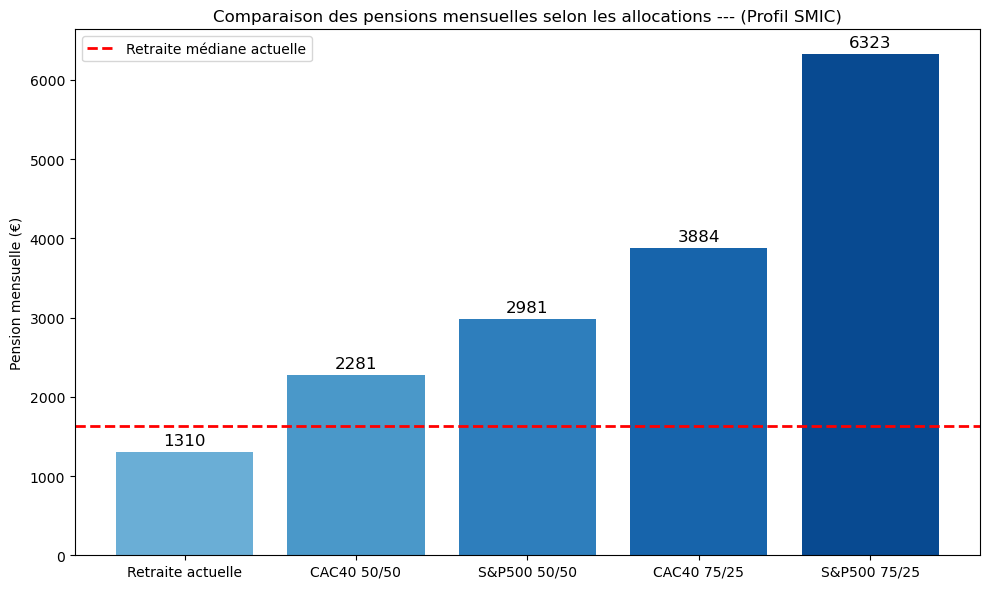

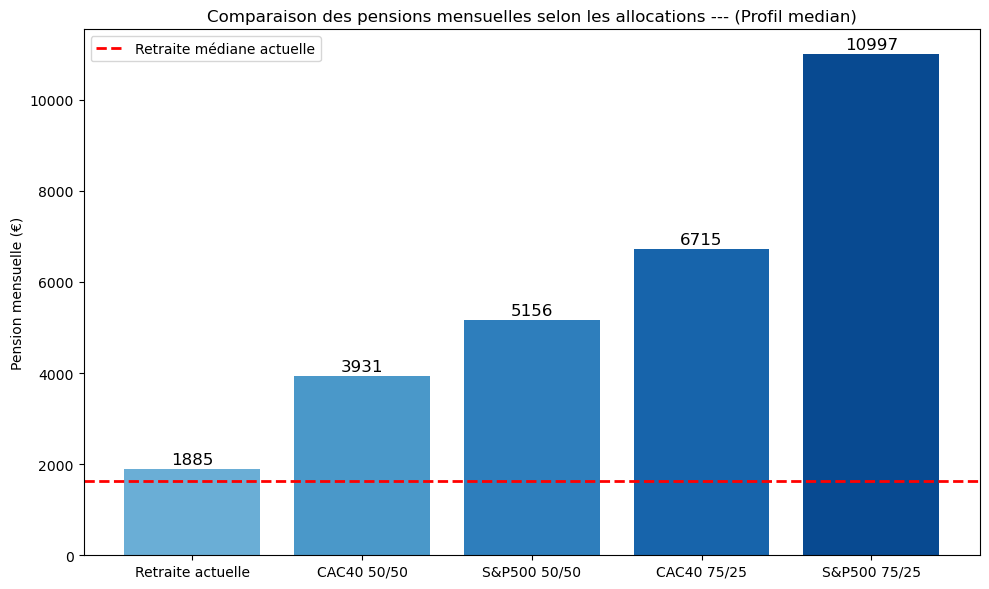

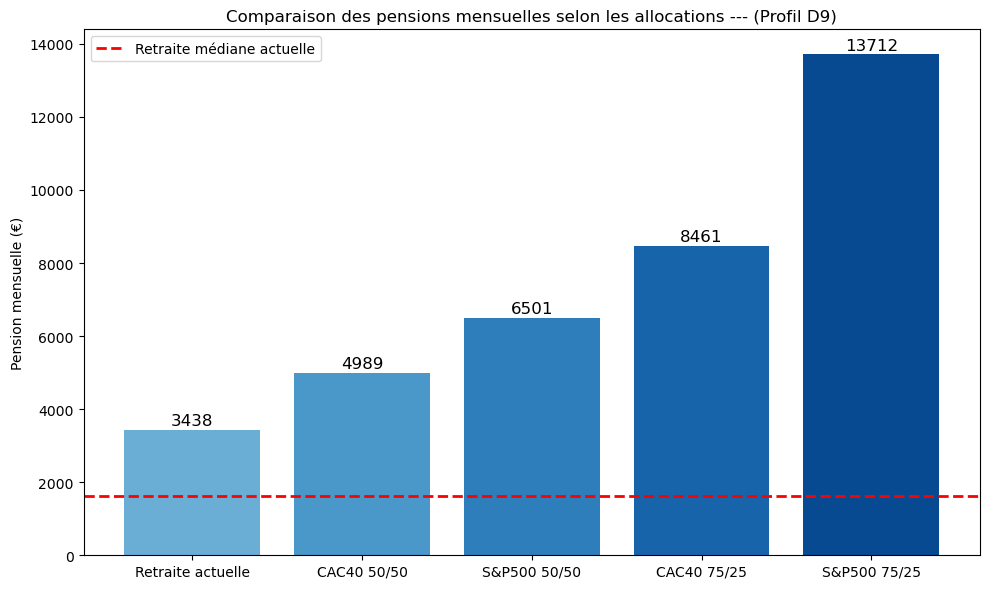

In [78]:
# Récupération des montants calculés
allocations = ['Retraite actuelle', 'CAC40 50/50', 'CAC40 75/25', 'S&P500 50/50', 'S&P500 75/25']
revenus = ["SMIC", "median", "D9"]

for revenu in revenus:
    if revenu == "SMIC":
        pensions = [retraite_actuelle_SMIC, pension_solidaire_cac_50_50_SMIC, pension_solidaire_cac_75_25_SMIC, pension_solidaire_snp_50_50_SMIC, pension_solidaire_snp_75_25_SMIC]
        allocations = ['Retraite actuelle', 'CAC40 50/50', 'S&P500 50/50', 'CAC40 75/25', 'S&P500 75/25']
    elif revenu == "median":
        pensions = [retraite_actuelle_median, pension_solidaire_cac_50_50_median, pension_solidaire_cac_75_25_median, pension_solidaire_snp_50_50_median, pension_solidaire_snp_75_25_median]
        allocations = ['Retraite actuelle', 'CAC40 50/50', 'S&P500 50/50', 'CAC40 75/25', 'S&P500 75/25']
    else:
        pensions = [retraite_actuelle_D9, pension_solidaire_cac_50_50_D9, pension_solidaire_cac_75_25_D9, pension_solidaire_snp_50_50_D9, pension_solidaire_snp_75_25_D9]
        allocations = ['Retraite actuelle', 'CAC40 50/50', 'S&P500 50/50', 'CAC40 75/25', 'S&P500 75/25']
    
    plt.figure(figsize=(10, 6))
    colors = plt.cm.Blues(np.linspace(0.5, 0.9, len(allocations)))  # Crée un gradient de bleu
    bars = plt.bar(allocations, pensions, color=colors)
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,  # Position du texte
                 f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=12)  # Affichage du montant
    plt.axhline(y=retraite_actuelle_médiane, color='red', linestyle='--', linewidth=2, label='Retraite médiane actuelle')
    plt.legend()
    plt.title(f"Comparaison des pensions mensuelles selon les allocations --- (Profil {revenu})")
    plt.ylabel("Pension mensuelle (€)")
    plt.tight_layout()
    plt.savefig(f"charts/comparaison_pensions_{revenu}.png", dpi=300, bbox_inches='tight')
    plt.show()

## 📌 Calcul des coefficients multiplicateurs

Pour terminer, et afin d’illustrer l’écart significatif entre les différents scénarios, nous calculons les **coefficients multiplicateurs** des pensions issues de chaque allocation par rapport à la **pension moyenne brute actuelle** du système par répartition (1 626 €).

🔹 Ces coefficients indiquent de combien la pension aurait été **multipliée** dans un système par capitalisation, selon l’allocation choisie.

Cela permet de visualiser très simplement le **gain potentiel** offert par un modèle capitalisé sur le long terme.

In [80]:
# Dictionnaire des pensions actuelles et solidaires par profil
pensions = {
    "SMIC": {
        "retraite_actuelle": retraite_actuelle_SMIC,
        "cac_50_50": pension_solidaire_cac_50_50_SMIC,
        "snp_50_50": pension_solidaire_snp_50_50_SMIC,
        "cac_75_25": pension_solidaire_cac_75_25_SMIC,
        "snp_75_25": pension_solidaire_snp_75_25_SMIC
    },
    "median": {
        "retraite_actuelle": retraite_actuelle_median,
        "cac_50_50": pension_solidaire_cac_50_50_median,
        "snp_50_50": pension_solidaire_snp_50_50_median,
        "cac_75_25": pension_solidaire_cac_75_25_median,
        "snp_75_25": pension_solidaire_snp_75_25_median
    },
    "D9": {
        "retraite_actuelle": retraite_actuelle_D9,
        "cac_50_50": pension_solidaire_cac_50_50_D9,
        "snp_50_50": pension_solidaire_snp_50_50_D9,
        "cac_75_25": pension_solidaire_cac_75_25_D9,
        "snp_75_25": pension_solidaire_snp_75_25_D9
    }
}

# Calcul et affichage des multiples pour chaque profil
for profil in ["SMIC", "median", "D9"]:
    print(f"\n=== Profil : {profil.upper()} ===")
    retraite_actuelle = pensions[profil]["retraite_actuelle"]
    allocations = {
        "CAC40 50/50": pensions[profil]["cac_50_50"] / retraite_actuelle,
        "S&P500 50/50": pensions[profil]["snp_50_50"] / retraite_actuelle,
        "CAC40 75/25": pensions[profil]["cac_75_25"] / retraite_actuelle,
        "S&P500 75/25": pensions[profil]["snp_75_25"] / retraite_actuelle
    }
    for allocation, multiple in allocations.items():
        print(f"Multiple {allocation}: --------- x{multiple:.2f}")


=== Profil : SMIC ===
Multiple CAC40 50/50: --------- x1.74
Multiple S&P500 50/50: --------- x2.97
Multiple CAC40 75/25: --------- x2.28
Multiple S&P500 75/25: --------- x4.83

=== Profil : MEDIAN ===
Multiple CAC40 50/50: --------- x2.09
Multiple S&P500 50/50: --------- x3.56
Multiple CAC40 75/25: --------- x2.74
Multiple S&P500 75/25: --------- x5.83

=== Profil : D9 ===
Multiple CAC40 50/50: --------- x1.45
Multiple S&P500 50/50: --------- x2.46
Multiple CAC40 75/25: --------- x1.89
Multiple S&P500 75/25: --------- x3.99


## **📌 Présentation des résultats**
Les résultats montrent que **toutes les allocations capitalisées surpassent largement le niveau des pensions actuelles**.  
Cette étude démontre qu’un **système de capitalisation bien structuré** aurait pu offrir des retraites **nettement supérieures** à celles du système actuel par répartition.

📌 **Observations clés** :\
✔️ **Le CAC40 seul offre déjà de meilleures pensions que le système actuel**, même sans effet de capitalisation massive.  
✔️ **Les allocations exposées au S&P500 produisent des pensions jusqu’à 6 fois plus élevées**, confirmant l’intérêt d’un modèle de capitalisation performant.  
✔️ **Même en intégrant un mécanisme de solidarité**, le système reste latgement plus soutenable qu’une répartition classique.


💡 **Ces résultats permettent d’ouvrir la discussion sur une réforme possible du financement des retraites en France.**

## 📌 Présentation des résultats

Les résultats montrent que **toutes les allocations capitalisées surpassent largement le niveau des pensions actuelles**.  
Cette étude démontre qu’un **système de capitalisation bien structuré** aurait pu offrir des retraites **nettement supérieures** à celles du système actuel par répartition.

### 📌 Observations clés :
✔️ **Le CAC40 seul offre déjà de meilleures pensions que le système actuel**, même sans bénéficier d’un effet de capitalisation massif.  
✔️ **Les allocations exposées au S&P500 produisent des pensions jusqu’à 6 fois plus élevées**, confirmant l’intérêt d’un modèle performant à long terme.  
✔️ **Même en intégrant un mécanisme de solidarité**, le système reste largement plus soutenable qu’une répartition classique.



💡 Il est essentiel de souligner que cette étude se concentre principalement sur le **niveau des pensions obtenues**, mais **le véritable atout d’un système par capitalisation va bien au-delà**.

### ✅ Un modèle structurellement viable

Contrairement au système par répartition, où les pensions des retraités dépendent directement des cotisations des actifs en temps réel, un modèle capitalisé repose **exclusivement sur l’effort individuel d’épargne et de cotisation**.  
Cela le rend **structurellement indépendant** :

- **Pas de dépendance à la démographie** (rapport actifs/retraités),
- **Pas de fragilité face au ralentissement économique ou à la baisse de la natalité**,
- **Pas de nécessité d’ajustements permanents via des réformes impopulaires**.

Chaque individu finance sa retraite en constituant **son propre capital**, ce qui rend le système à la fois **prévisible**, **équitable** et **pérenne**.

---

📌 **Ces résultats ouvrent la voie à une réflexion approfondie sur les fondements du financement des retraites en France**, et sur la possibilité d’introduire un **modèle hybride**, combinant **efficacité économique** et **solidarité ciblée**.

---

🗣️ **Ouvert aux remarques et discussions constructives**  
Ce travail est une première base de réflexion et reste perfectible. Toute remarque, critique ou suggestion permettant d’enrichir le modèle ou d’ouvrir de nouvelles pistes d’analyse est la bienvenue.